<a href="https://colab.research.google.com/github/MDAnsaar25/Mushroom-Classification-and-Analysis/blob/main/Mushroom_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('dark')

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn import metrics

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
mushroom= pd.read_csv('/content/drive/MyDrive/Data Sets/mushrooms.csv')

In [6]:
mushroom.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [7]:
mushroom.tail(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [8]:
mushroom.duplicated().sum()

np.int64(0)

In [9]:
mushroom.isnull().sum() #Checking null values

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [10]:
mushroom.shape

(8124, 23)

In [11]:
mushroom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [12]:
mushroom['class'].value_counts().to_frame()   #number of edible(e)and  poisonous(p) Mashrooms

,count
class,
e,4208
p,3916


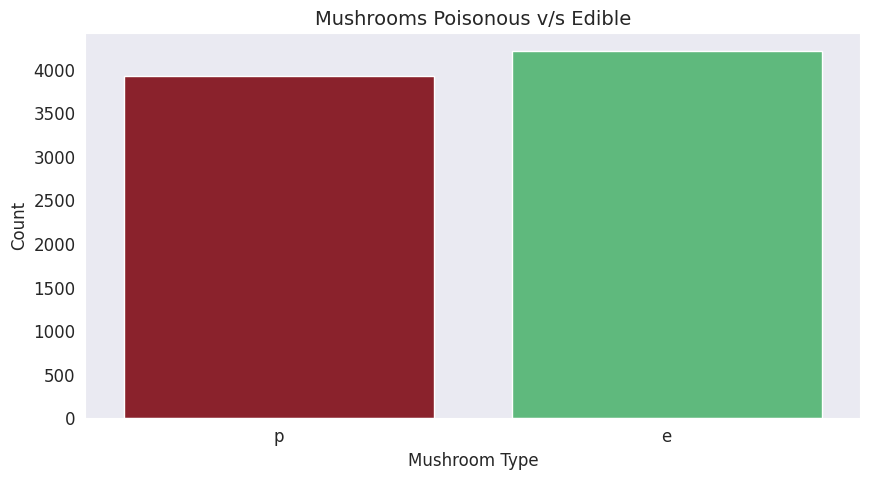

In [13]:
plt.figure(figsize=(10,5))
plt.title('Mushrooms Poisonous v/s Edible', fontsize=14)
sns.countplot(x="class", data=mushroom, palette=('#9b111e','#50c878'))
plt.xlabel("Mushroom Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

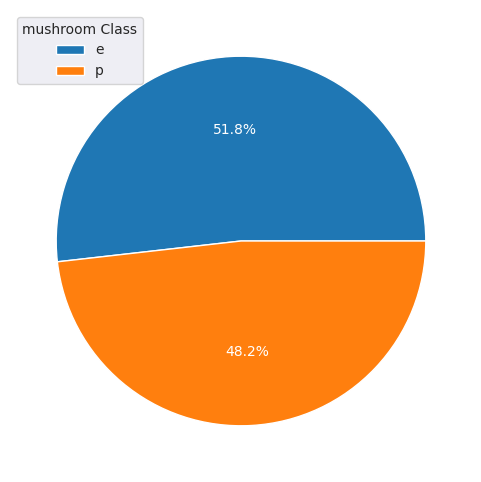

In [14]:
# pie chart

# prepare the data for plotting
# create a dictionary of classes and their totals
d = mushroom["class"].value_counts().to_dict()

# instanciate the figure
fig = plt.figure(figsize = (18, 6))
ax = fig.add_subplot()

# plot the data using matplotlib
ax.pie(d.values(), # pass the values from our dictionary
       labels = d.keys(), # pass the labels from our dictonary
       autopct = '%1.1f%%', # specify the format to be plotted %age
       textprops = {'fontsize': 10, 'color' : "white"} # change the font size and the color of the numbers inside the pie
      )
# set the legend and add a title to the legend
ax.legend(loc = "upper left", title = "mushroom Class")
plt.show()

In [15]:
mushroom.groupby(['cap-shape'])['class'].value_counts().to_frame()

count
cap-shape class       
b         e        404
          p         48
c         p          4
f         e       1596
          p       1556
k         p        600
          e        228
s         e         32
x         e       1948
          p       1708

In [16]:
mushroom.groupby(['cap-surface'])['class'].value_counts().to_frame()

count
cap-surface class       
f           e       1560
            p        760
g           p          4
s           p       1412
            e       1144
y           p       1740
            e       1504

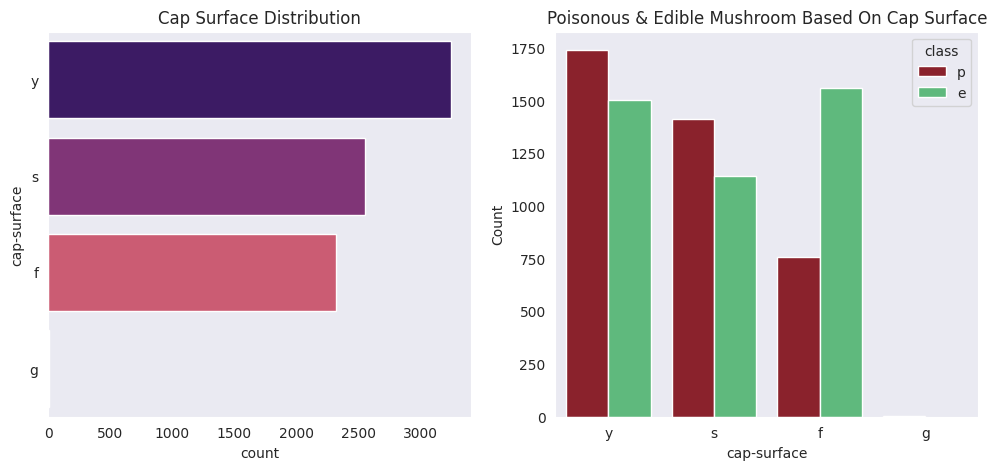

In [17]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['cap-surface'], ax=axarr[0], order=mushroom['cap-surface'].value_counts().index, palette="magma").set_title('Cap Surface Distribution')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Cap Surface')
b = sns.countplot(x="cap-surface", data=mushroom, hue="class", order=mushroom['cap-surface'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

In [18]:
mushroom.groupby(['cap-color'])['class'].value_counts().to_frame()

count
cap-color class       
b         p        120
          e         48
c         e         32
          p         12
e         p        876
          e        624
g         e       1032
          p        808
n         e       1264
          p       1020
p         p         88
          e         56
r         e         16
u         e         16
w         e        720
          p        320
y         p        672
          e        400

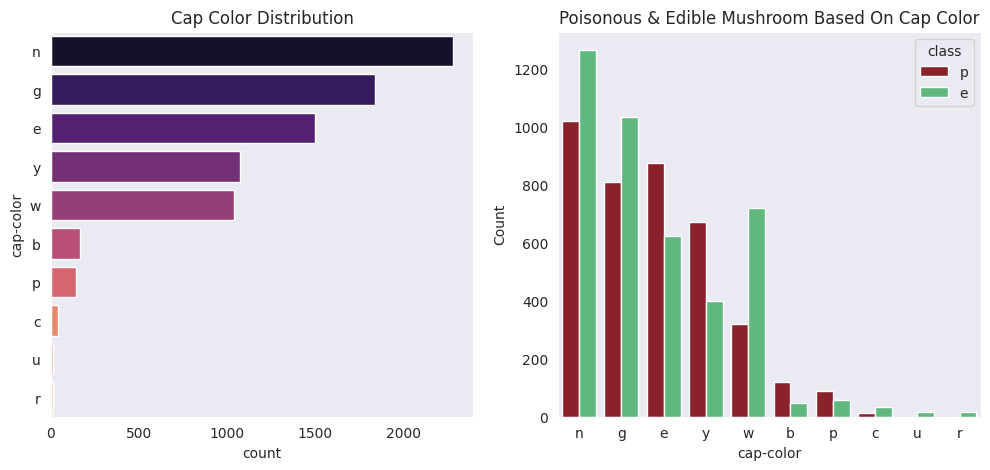

In [19]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['cap-color'], ax=axarr[0], order=mushroom['cap-color'].value_counts().index, palette="magma").set_title('Cap Color Distribution')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Cap Color')
b = sns.countplot(x="cap-color", data=mushroom, hue="class", order=mushroom['cap-color'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

In [20]:
mushroom.groupby(['bruises'])['class'].value_counts().to_frame()

count
bruises class       
f       p       3292
        e       1456
t       e       2752
        p        624

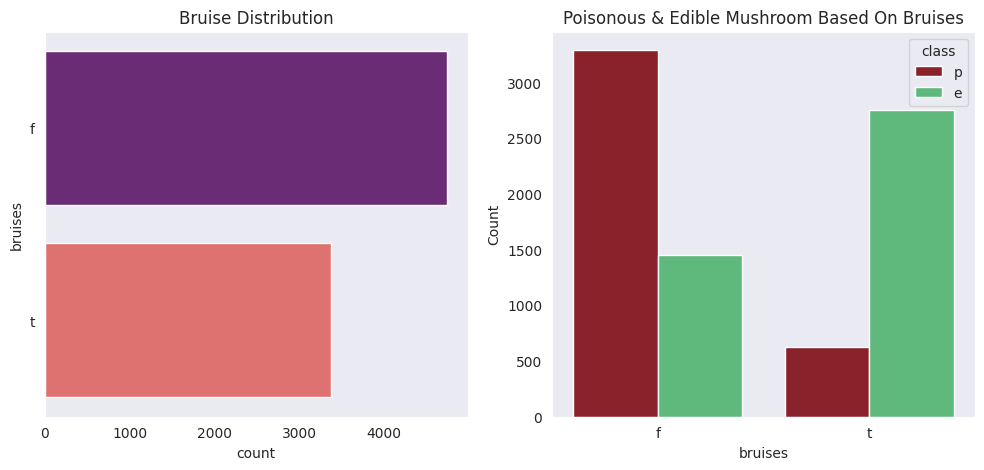

In [21]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['bruises'], ax=axarr[0], order=mushroom['bruises'].value_counts().index, palette="magma").set_title('Bruise Distribution')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Bruises')
b = sns.countplot(x="bruises", data=mushroom, hue="class", order=mushroom['bruises'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Odor

In [22]:
mushroom.groupby(['odor'])['class'].value_counts().to_frame()

count
odor class       
a    e        400
c    p        192
f    p       2160
l    e        400
m    p         36
n    e       3408
     p        120
p    p        256
s    p        576
y    p        576

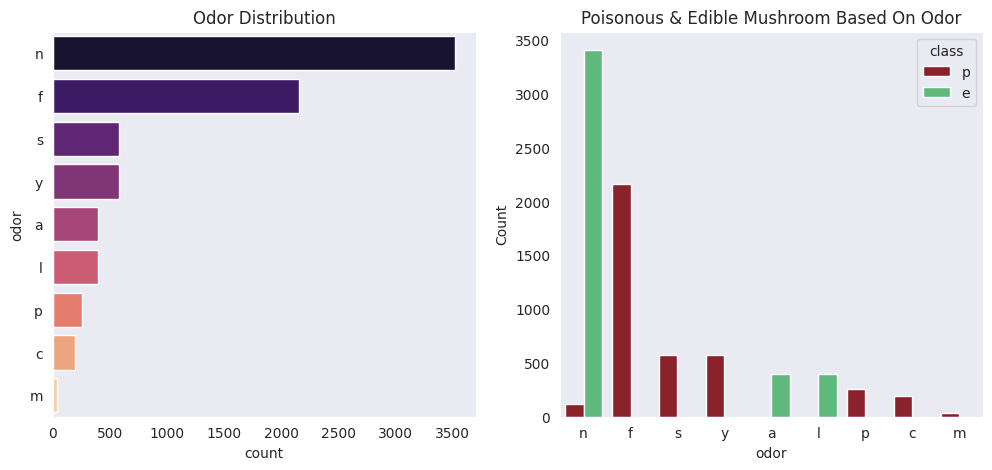

In [23]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['odor'], ax=axarr[0], order=mushroom['odor'].value_counts().index, palette="magma").set_title('Odor Distribution')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Odor')
b = sns.countplot(x="odor", data=mushroom, hue="class", order=mushroom['odor'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Gill Attachment

In [24]:
mushroom.groupby(['gill-attachment'])['class'].value_counts().to_frame()

count
gill-attachment class       
a               e        192
                p         18
f               e       4016
                p       3898

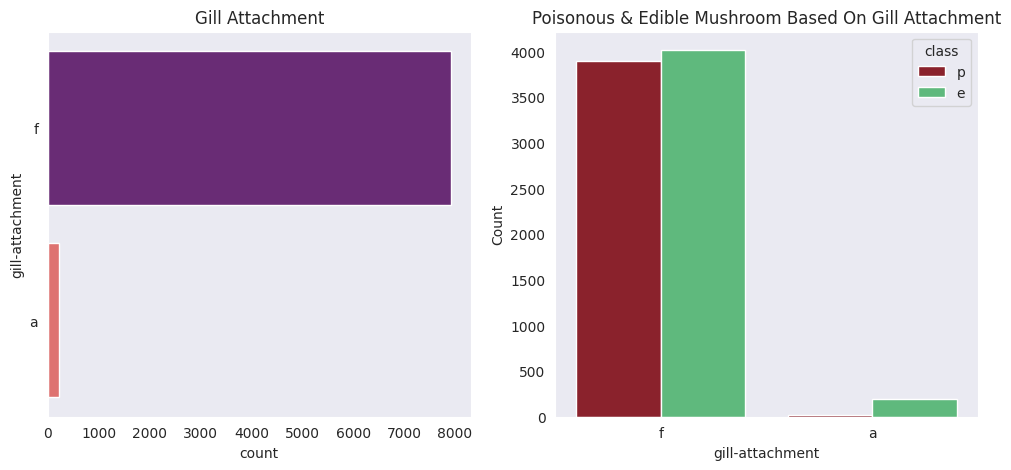

In [25]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['gill-attachment'], ax=axarr[0], order=mushroom['gill-attachment'].value_counts().index, palette="magma").set_title('Gill Attachment')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Gill Attachment')
b = sns.countplot(x="gill-attachment", data=mushroom, hue="class", order=mushroom['gill-attachment'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Gill Spacing

In [26]:
mushroom.groupby(['gill-spacing'])['class'].value_counts().to_frame()

count
gill-spacing class       
c            p       3804
             e       3008
w            e       1200
             p        112

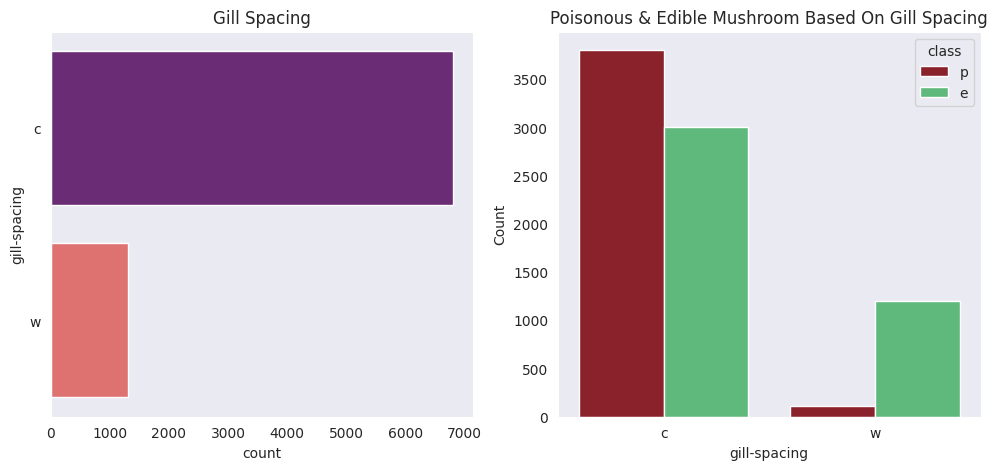

In [27]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['gill-spacing'], ax=axarr[0], order=mushroom['gill-spacing'].value_counts().index, palette="magma").set_title('Gill Spacing')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Gill Spacing')
b = sns.countplot(x="gill-spacing", data=mushroom, hue="class", order=mushroom['gill-spacing'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Gill Size

In [28]:
mushroom.groupby(['gill-size'])['class'].value_counts().to_frame()

count
gill-size class       
b         e       3920
          p       1692
n         p       2224
          e        288

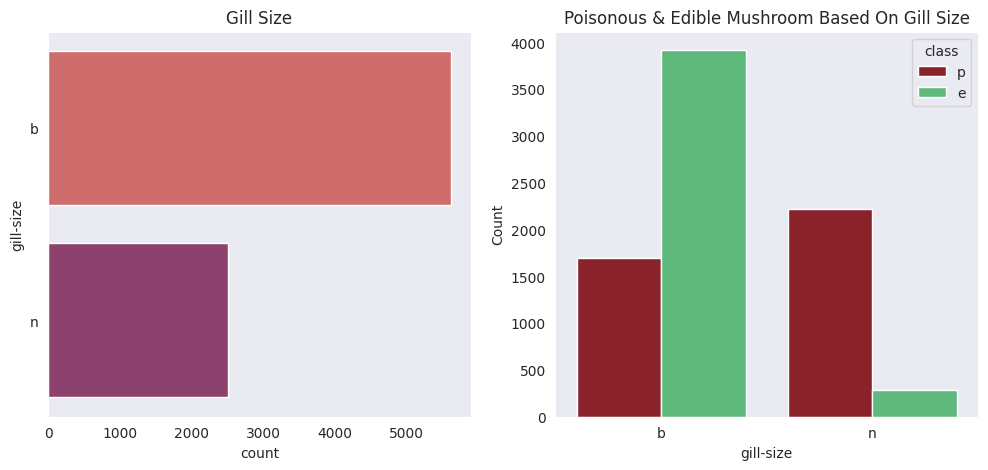

In [29]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['gill-size'], ax=axarr[0], order=mushroom['gill-size'].value_counts().index, palette="flare").set_title('Gill Size')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Gill Size')
b = sns.countplot(x="gill-size", data=mushroom, hue="class", order=mushroom['gill-size'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Gill Color

In [30]:
mushroom.groupby(['gill-color'])['class'].value_counts().to_frame()

count
gill-color class       
b          p       1728
e          e         96
g          p        504
           e        248
h          p        528
           e        204
k          e        344
           p         64
n          e        936
           p        112
o          e         64
p          e        852
           p        640
r          p         24
u          e        444
           p         48
w          e        956
           p        246
y          e         64
           p         22

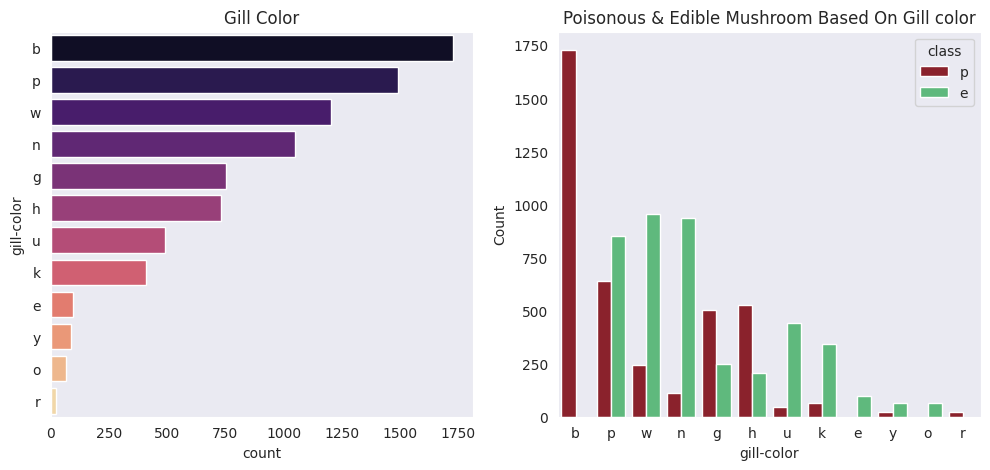

In [31]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['gill-color'], ax=axarr[0], order=mushroom['gill-color'].value_counts().index, palette="magma").set_title('Gill Color')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Gill color')
b = sns.countplot(x="gill-color", data=mushroom, hue="class", order=mushroom['gill-color'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Shape

In [32]:
mushroom.groupby(['stalk-shape'])['class'].value_counts().to_frame()

count
stalk-shape class       
e           p       1900
            e       1616
t           e       2592
            p       2016

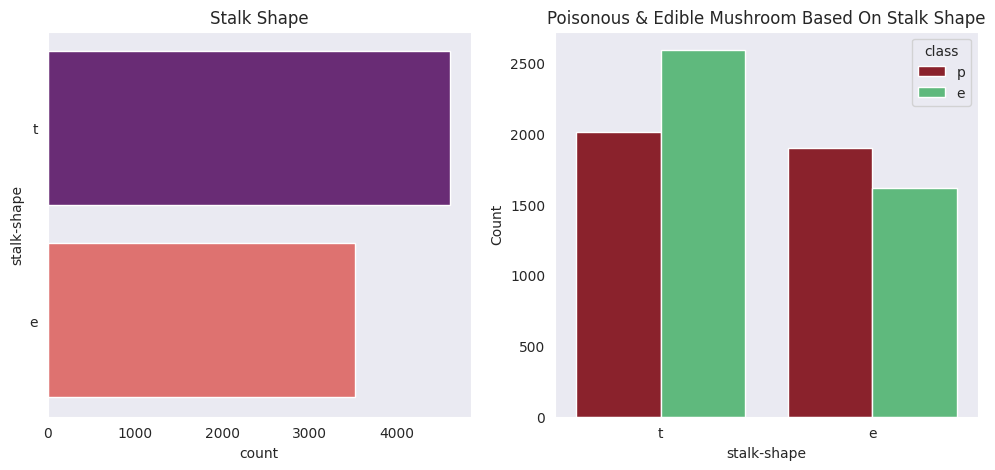

In [33]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-shape'], ax=axarr[0], order=mushroom['stalk-shape'].value_counts().index, palette="magma").set_title('Stalk Shape')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Shape')
b = sns.countplot(x="stalk-shape", data=mushroom, hue="class", order=mushroom['stalk-shape'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Surface Above Ring

In [34]:
mushroom.groupby(['stalk-surface-above-ring'])['class'].value_counts().to_frame()

count
stalk-surface-above-ring class       
f                        e        408
                         p        144
k                        p       2228
                         e        144
s                        e       3640
                         p       1536
y                        e         16
                         p          8

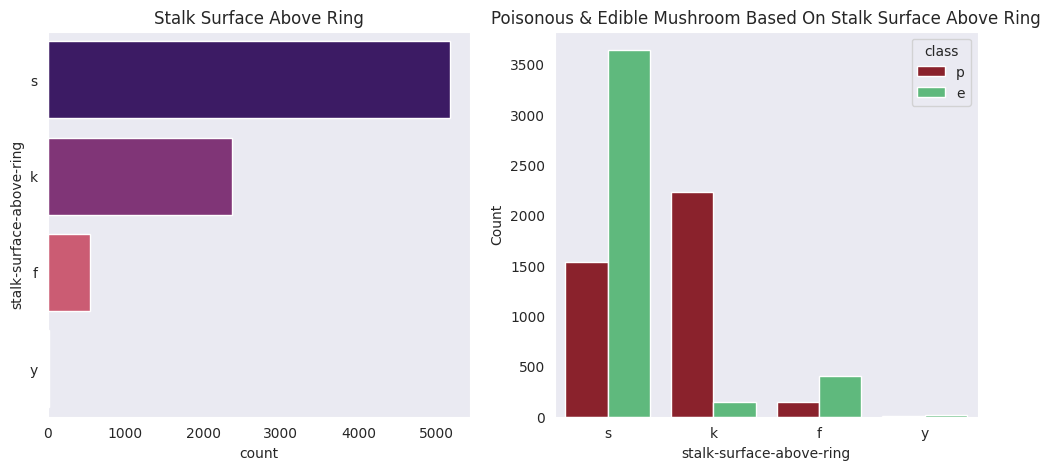

In [35]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-surface-above-ring'], ax=axarr[0], order=mushroom['stalk-surface-above-ring'].value_counts().index, palette="magma").set_title('Stalk Surface Above Ring')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Surface Above Ring')
b = sns.countplot(x="stalk-surface-above-ring", data=mushroom, hue="class", order=mushroom['stalk-surface-above-ring'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Surface Below Ring

In [36]:
mushroom.groupby(['stalk-surface-below-ring'])['class'].value_counts().to_frame()

count
stalk-surface-below-ring class       
f                        e        456
                         p        144
k                        p       2160
                         e        144
s                        e       3400
                         p       1536
y                        e        208
                         p         76

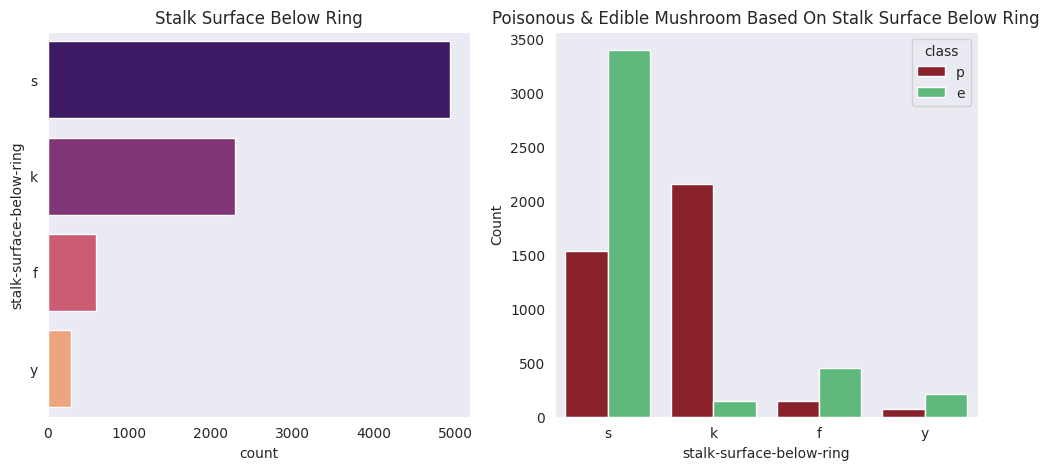

In [37]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-surface-below-ring'], order=mushroom['stalk-surface-below-ring'].value_counts().index, ax=axarr[0], palette="magma").set_title('Stalk Surface Below Ring')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Surface Below Ring')
b = sns.countplot(x="stalk-surface-below-ring", data=mushroom, hue="class", order=mushroom['stalk-surface-below-ring'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Color Above Ring

In [38]:
mushroom.groupby(['stalk-color-above-ring'])['class'].value_counts().to_frame()

count
stalk-color-above-ring class       
b                      p        432
c                      p         36
e                      e         96
g                      e        576
n                      p        432
                       e         16
o                      e        192
p                      p       1296
                       e        576
w                      e       2752
                       p       1712
y                      p          8

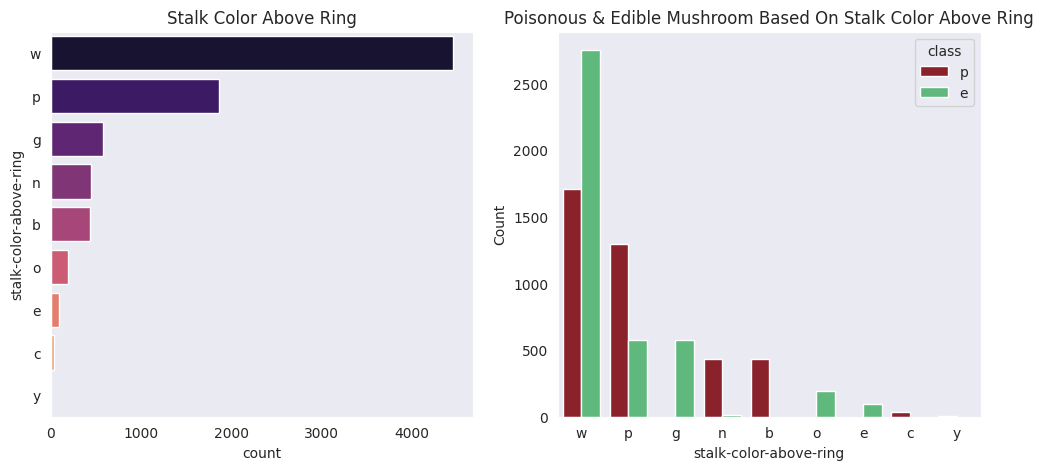

In [39]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-color-above-ring'], ax=axarr[0], order=mushroom['stalk-color-above-ring'].value_counts().index, palette="magma").set_title('Stalk Color Above Ring')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Color Above Ring')
b = sns.countplot(x="stalk-color-above-ring", data=mushroom, hue="class", order=mushroom['stalk-color-above-ring'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Color Below Ring

In [40]:
mushroom.groupby(['stalk-color-below-ring'])['class'].value_counts().to_frame()

count
stalk-color-below-ring class       
b                      p        432
c                      p         36
e                      e         96
g                      e        576
n                      p        448
                       e         64
o                      e        192
p                      p       1296
                       e        576
w                      e       2704
                       p       1680
y                      p         24

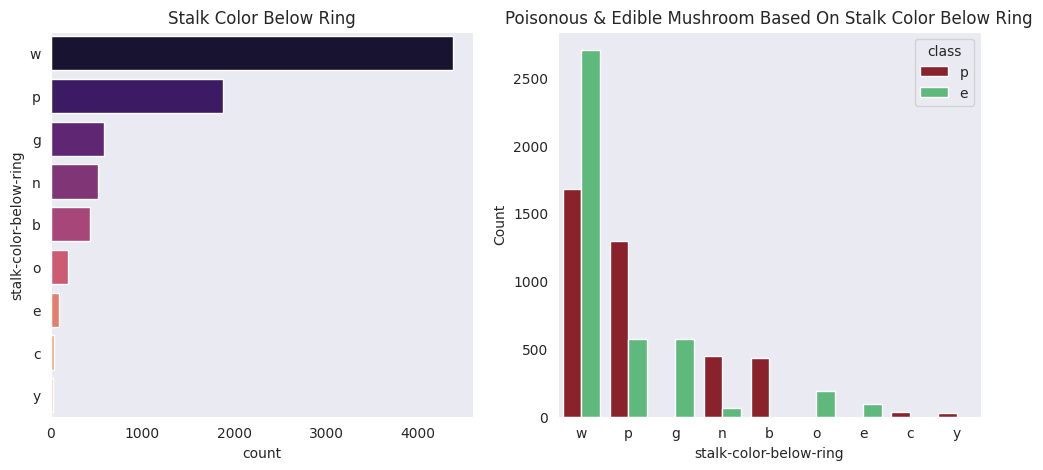

In [41]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-color-below-ring'], order=mushroom['stalk-color-below-ring'].value_counts().index, ax=axarr[0], palette="magma").set_title('Stalk Color Below Ring')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Color Below Ring')
b = sns.countplot(x="stalk-color-below-ring", data=mushroom, hue="class", order=mushroom['stalk-color-below-ring'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Veil Type

In [42]:
mushroom.groupby(['veil-type'])['class'].value_counts().to_frame()

count
veil-type class       
p         e       4208
          p       3916

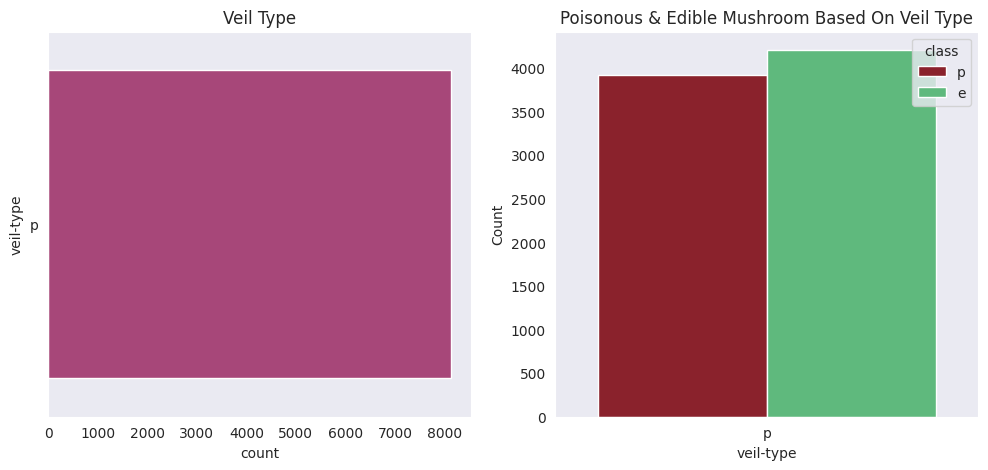

In [43]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['veil-type'], ax=axarr[0], palette="magma").set_title('Veil Type')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Veil Type')
b = sns.countplot(x="veil-type", data=mushroom, hue="class", palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Veil Color

In [44]:
mushroom.groupby(['veil-color'])['class'].value_counts().to_frame()

count
veil-color class       
n          e         96
o          e         96
w          e       4016
           p       3908
y          p          8

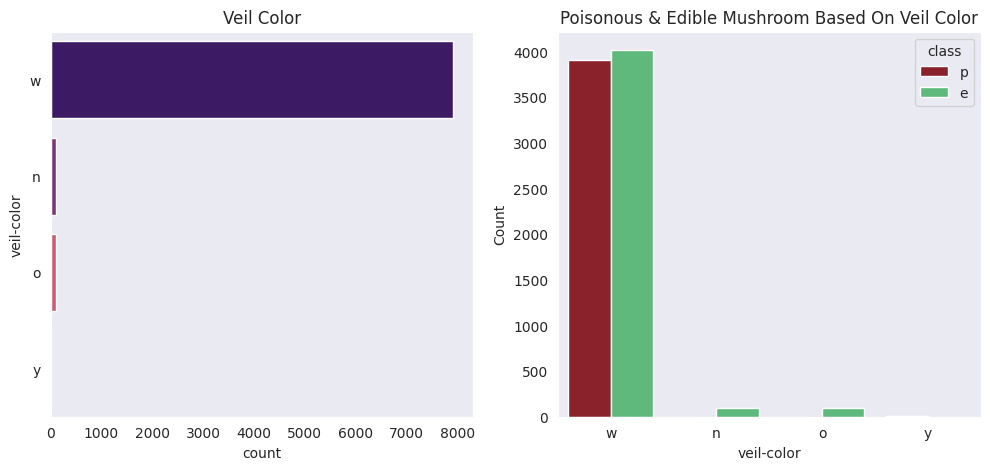

In [45]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['veil-color'], ax=axarr[0], order=mushroom['veil-color'].value_counts().index, palette="magma").set_title('Veil Color')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Veil Color')
b = sns.countplot(x="veil-color", data=mushroom, hue="class", order=mushroom['veil-color'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Ring Number

In [46]:
mushroom.groupby(['ring-number'])['class'].value_counts().to_frame()

count
ring-number class       
n           p         36
o           p       3808
            e       3680
t           e        528
            p         72

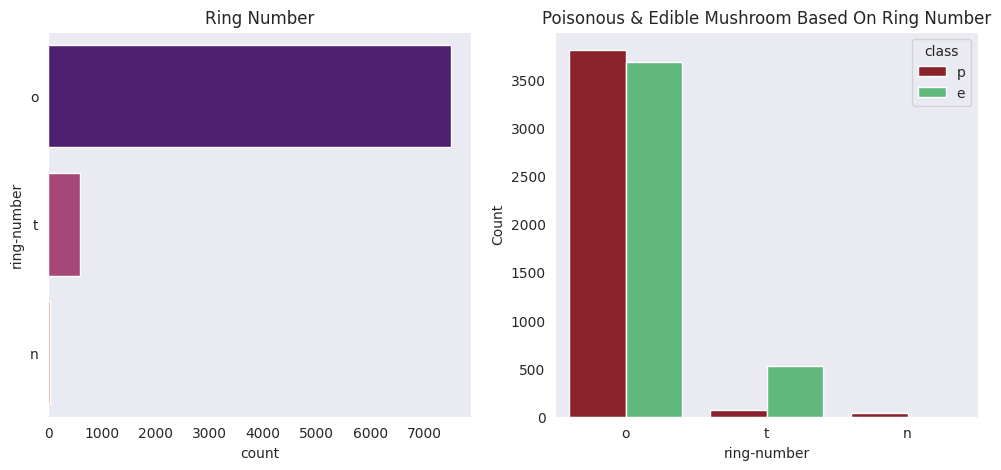

In [47]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['ring-number'], ax=axarr[0], order=mushroom['ring-number'].value_counts().index, palette="magma").set_title('Ring Number')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Ring Number')
b = sns.countplot(x="ring-number", data=mushroom, hue="class", order=mushroom['ring-number'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Observations:
1(o) ring number mushrooms are more in number and hard to classify.
No ring(n) mushrooms are very less in numbers and all of them are poisonous.
2(t) ring number mushrooms are mostly edible.

#Ring Type

In [48]:
mushroom.groupby(['ring-type'])['class'].value_counts().to_frame()

count
ring-type class       
e         p       1768
          e       1008
f         e         48
l         p       1296
n         p         36
p         e       3152
          p        816

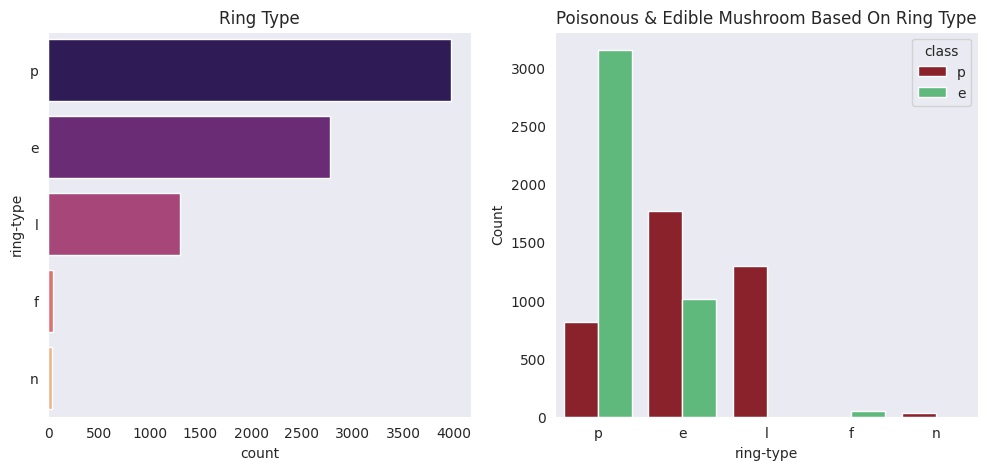

In [49]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['ring-type'], ax=axarr[0], order=mushroom['ring-type'].value_counts().index, palette="magma").set_title('Ring Type')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Ring Type')
b = sns.countplot(x="ring-type", data=mushroom, hue="class", order=mushroom['ring-type'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Observations:
Pendant(p) ring type mushrooms are more in number and most of them are edible.
All large(l) ring type mushrooms are poisonous.

#Spore Print Color

In [50]:
mushroom.groupby(['spore-print-color'])['class'].value_counts().to_frame()

count
spore-print-color class       
b                 e         48
h                 p       1584
                  e         48
k                 e       1648
                  p        224
n                 e       1744
                  p        224
o                 e         48
r                 p         72
u                 e         48
w                 p       1812
                  e        576
y                 e         48

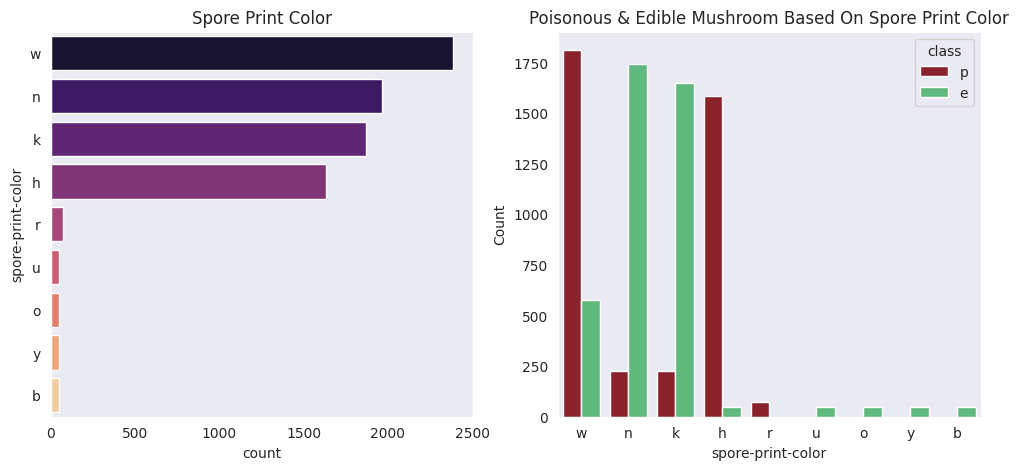

In [51]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['spore-print-color'], order=mushroom['spore-print-color'].value_counts().index, ax=axarr[0], palette="magma").set_title('Spore Print Color')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Spore Print Color')
b = sns.countplot(x="spore-print-color", data=mushroom, hue="class", order=mushroom['spore-print-color'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Observations:
White(w) spore print color mushrooms are more followed by brown(n), black(k) & chocolate(h)
More than 80% of black(k) & brown(n) spore print color mushrooms are edible.
More than 80% of white(w) & chocolate(h) spore print color mushrooms are poisonous.
This can also be one of the most important feature while classifying mushrooms.

#Population

In [52]:
mushroom.groupby(['population'])['class'].value_counts().to_frame()

count
population class       
a          e        384
c          e        288
           p         52
n          e        400
s          e        880
           p        368
v          p       2848
           e       1192
y          e       1064
           p        648

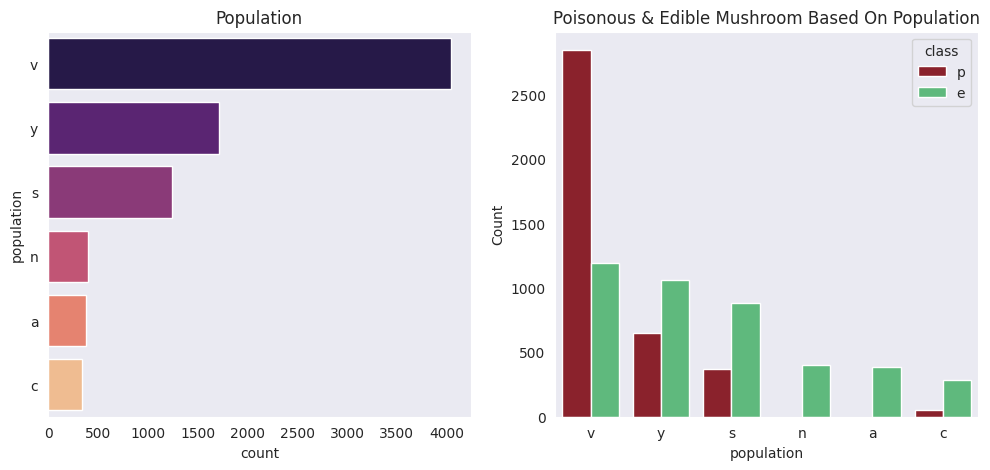

In [53]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['population'], ax=axarr[0], order=mushroom['population'].value_counts().index, palette="magma").set_title('Population')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Population')
b = sns.countplot(x="population", data=mushroom, hue="class", order=mushroom['population'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Observations:
Population type several(p) mushrooms are more in numbers and most of them are poisonous.
All numerous(n) and abundant(a) population type mushrooms are edible.
Most of the scattered(s) & solitary(y) mushrooms are also edible.

#Habitat

In [54]:
mushroom.groupby(['habitat'])['class'].value_counts().to_frame()

count
habitat class       
d       e       1880
        p       1268
g       e       1408
        p        740
l       p        592
        e        240
m       e        256
        p         36
p       p       1008
        e        136
u       p        272
        e         96
w       e        192

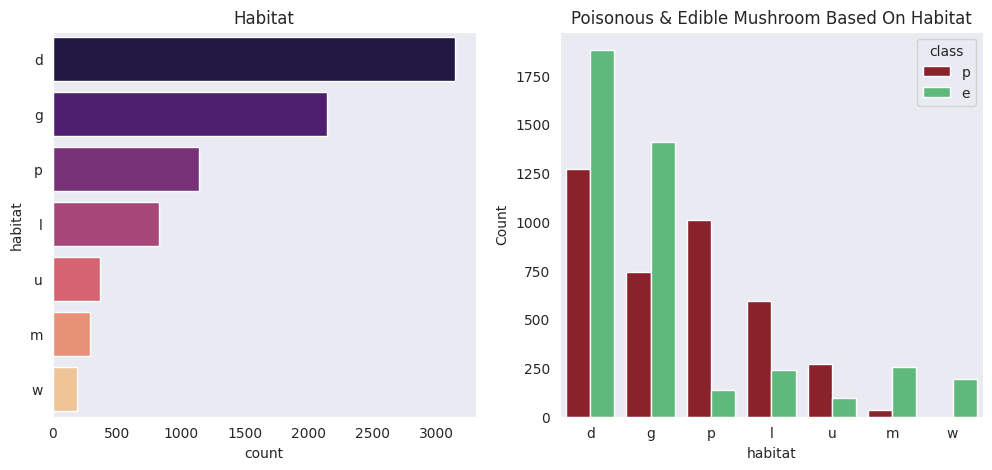

In [55]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['habitat'], ax=axarr[0], order=mushroom['habitat'].value_counts().index, palette="magma").set_title('Habitat')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Habitat')
b = sns.countplot(x="habitat", data=mushroom, hue="class", order=mushroom['habitat'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Observations:
Mushrooms those found in woods(d) are more in number and most of them are edible.
Most of the mushrooms found in the grass(g) are also edible
Also, all the mushrooms found on the waste(w) are edible.

#Check all variable in respect of classes.

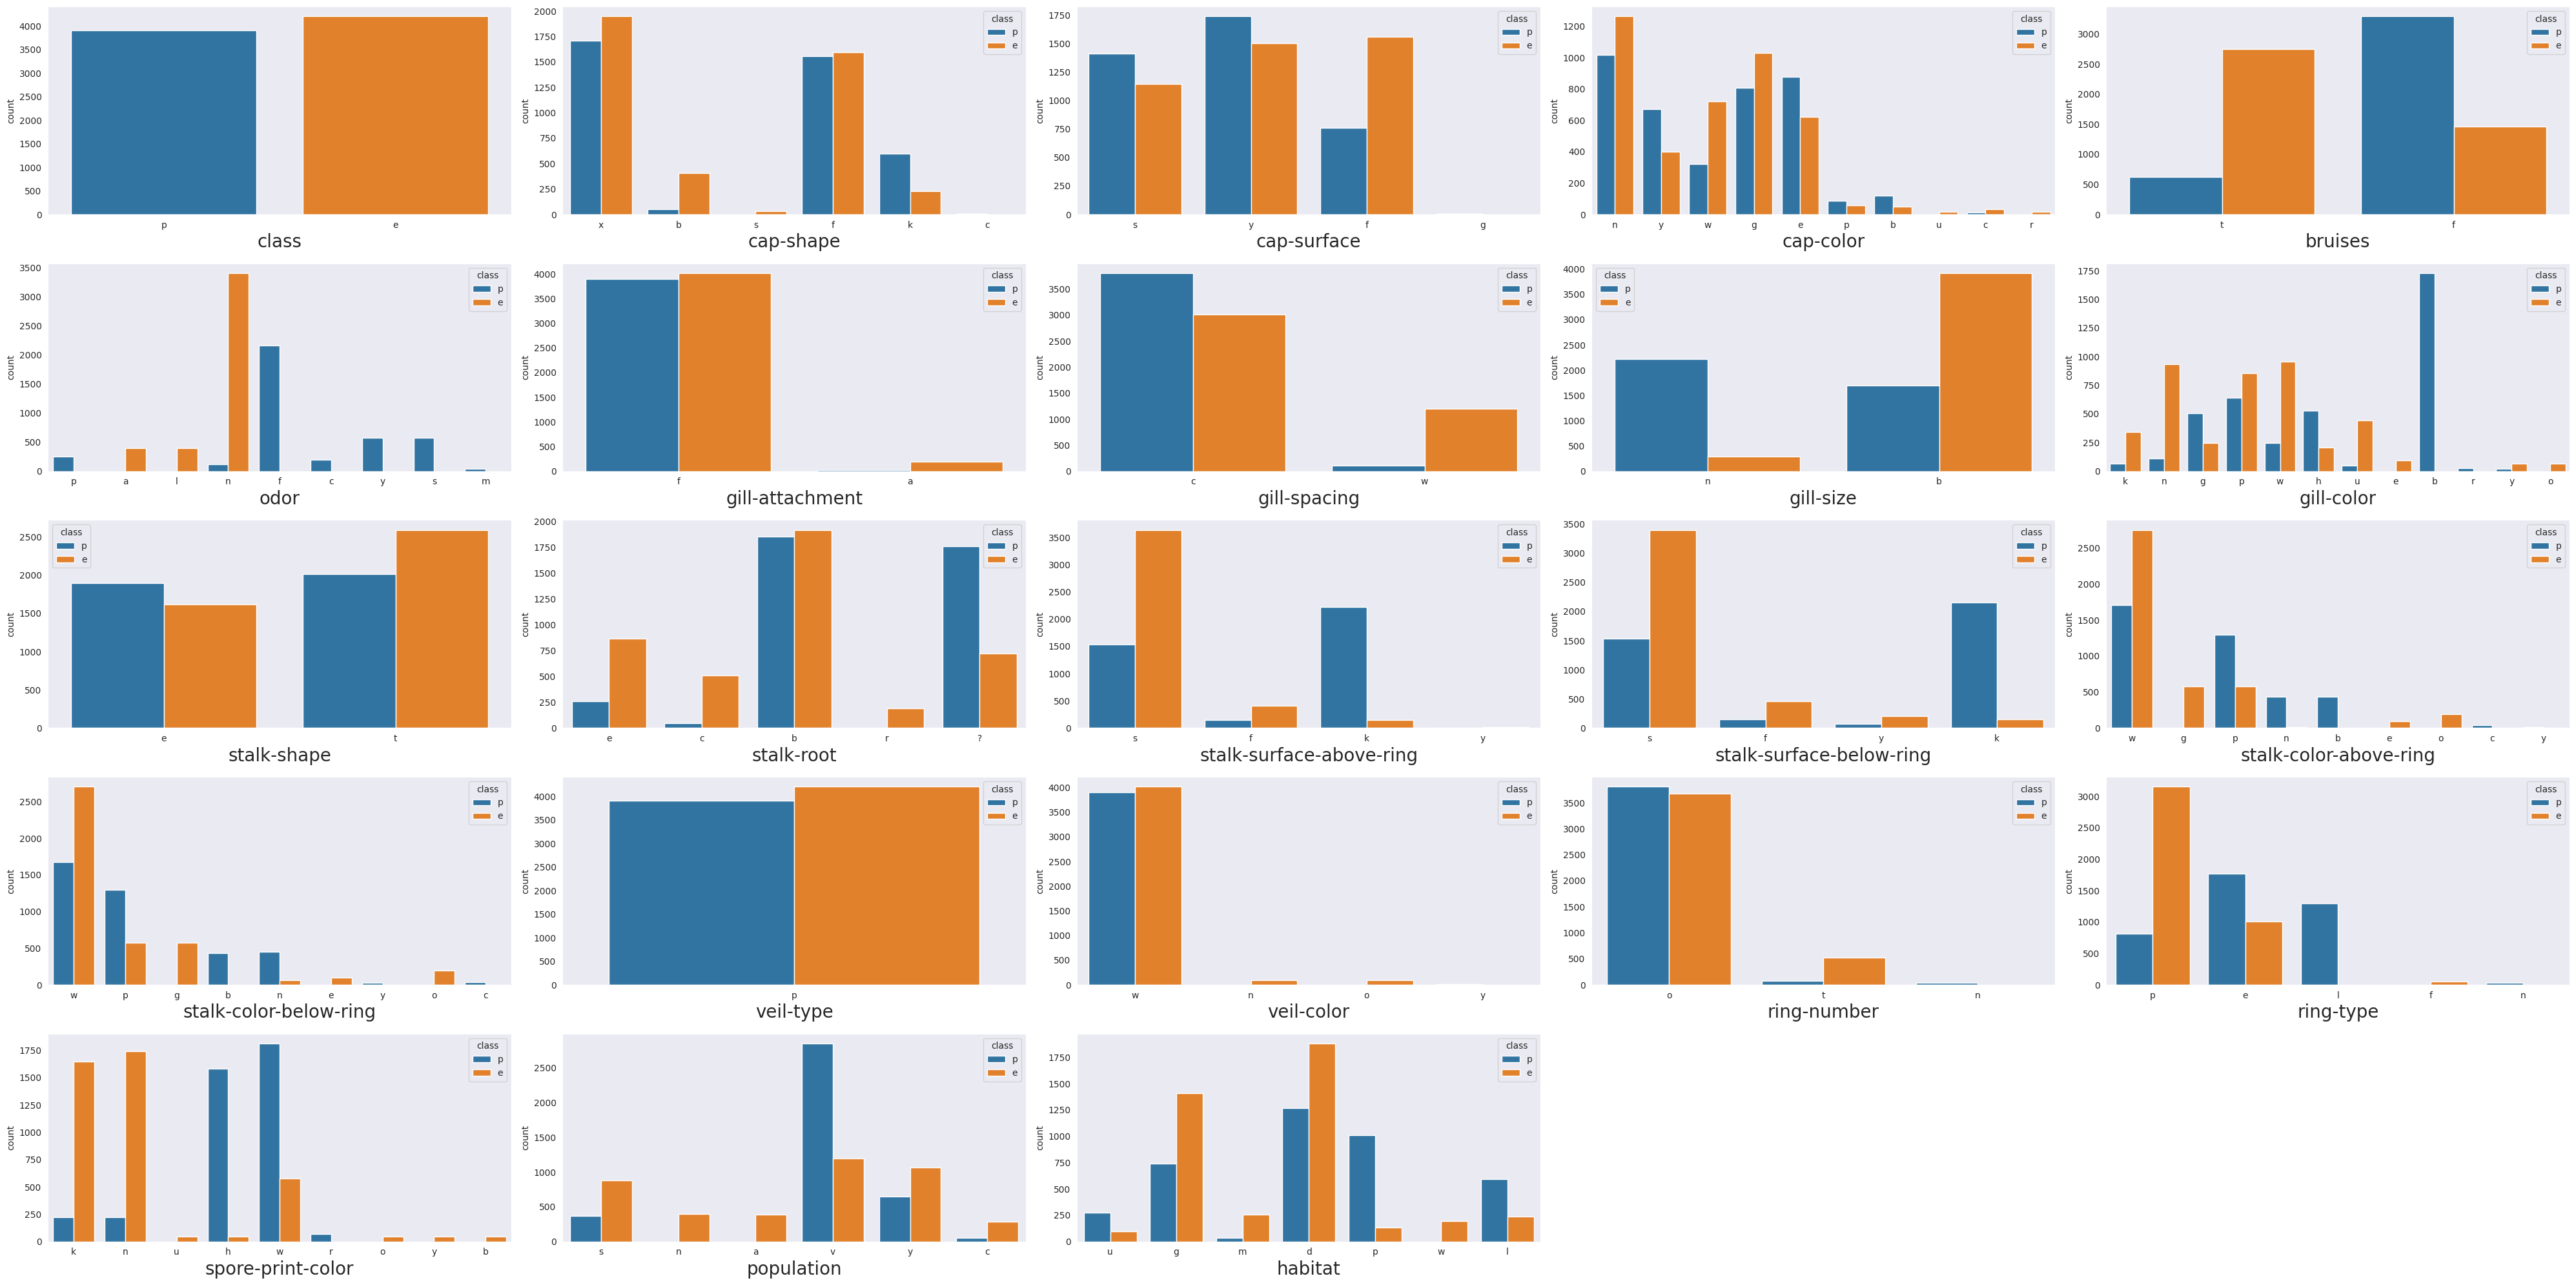

In [56]:
cols = list(mushroom.columns) # get list pf columns
plt.figure(figsize=(40,20))
#enumerate() function takes in an iterable as an argument, such as a list, string, tuple, or dictionary and allows us to iterate through a sequence but it keeps track of both the index and the element
for i in enumerate(cols):
    plt.subplot(5,5,i[0]+1)
    ax = sns.countplot(x=i[1],hue='class',data=mushroom)
    ax.set_xlabel(i[1],fontsize=20)
plt.tight_layout() #adjusts subplot so that the all subplots fits in to the figure area
plt.show()

#Data Preperation For Modelling

Drop Unnecessary Columns
First, the columns which only take one value can be dropped. Let's see unique values from each columns.

In [57]:
mushroom.nunique() #check number of unique values from each columns.

,0
class,2
cap-shape,6
cap-surface,4
cap-color,10
bruises,2
odor,9
gill-attachment,2
gill-spacing,2
gill-size,2
gill-color,12


In [58]:
## let's check some variable with imbalance lebels
## as observed in data analysis all the veil type mashroom are poisonous
mushroom['veil-type'].value_counts()/mushroom.shape[0]

,count
veil-type,
p,1.0


As variable 'vail-type' has only one value hence remove this variable from the dataframe and all mushrooms are poisonous.

In [59]:
mushroom.drop(columns=['veil-type'], axis=1, inplace=True) ##  remove Veil-type column
mushroom.shape ## check final shape

(8124, 22)

#

### Convert Values To Integers
For converting, we will use label encoding

In [60]:
#Define a function to use label encoding for each feature

def Label_enc(feature):
    LE = LabelEncoder()
    LE.fit(feature)
    print(feature.name,LE.classes_) # printing each feature name with encoded classes
    return LE.transform(feature)

In [61]:
# implementing label encoding to each column feature
for col in mushroom.columns:
    mushroom[str(col)] = Label_enc(mushroom[str(col)])

class ['e' 'p']
cap-shape ['b' 'c' 'f' 'k' 's' 'x']
cap-surface ['f' 'g' 's' 'y']
cap-color ['b' 'c' 'e' 'g' 'n' 'p' 'r' 'u' 'w' 'y']
bruises ['f' 't']
odor ['a' 'c' 'f' 'l' 'm' 'n' 'p' 's' 'y']
gill-attachment ['a' 'f']
gill-spacing ['c' 'w']
gill-size ['b' 'n']
gill-color ['b' 'e' 'g' 'h' 'k' 'n' 'o' 'p' 'r' 'u' 'w' 'y']
stalk-shape ['e' 't']
stalk-root ['?' 'b' 'c' 'e' 'r']
stalk-surface-above-ring ['f' 'k' 's' 'y']
stalk-surface-below-ring ['f' 'k' 's' 'y']
stalk-color-above-ring ['b' 'c' 'e' 'g' 'n' 'o' 'p' 'w' 'y']
stalk-color-below-ring ['b' 'c' 'e' 'g' 'n' 'o' 'p' 'w' 'y']
veil-color ['n' 'o' 'w' 'y']
ring-number ['n' 'o' 't']
ring-type ['e' 'f' 'l' 'n' 'p']
spore-print-color ['b' 'h' 'k' 'n' 'o' 'r' 'u' 'w' 'y']
population ['a' 'c' 'n' 's' 'v' 'y']
habitat ['d' 'g' 'l' 'm' 'p' 'u' 'w']


#Modelling

Let's define x and y and split them. Here 'class' column is our decision label as it will give us final predication ( e/p type)

In [62]:
x = mushroom.drop(columns=['class'], axis=1) # seprating decision label
y = mushroom['class'] #decision label

In [63]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0) ## split data in train and test

#Random Forest Algortihms

In [64]:
model = RandomForestClassifier()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

In [65]:
y_predict== y_test # comparing the predicted category with actual category

,class
380,True
3641,True
273,True
1029,True
684,True
...,...
520,True
36,True
7959,True
6520,True


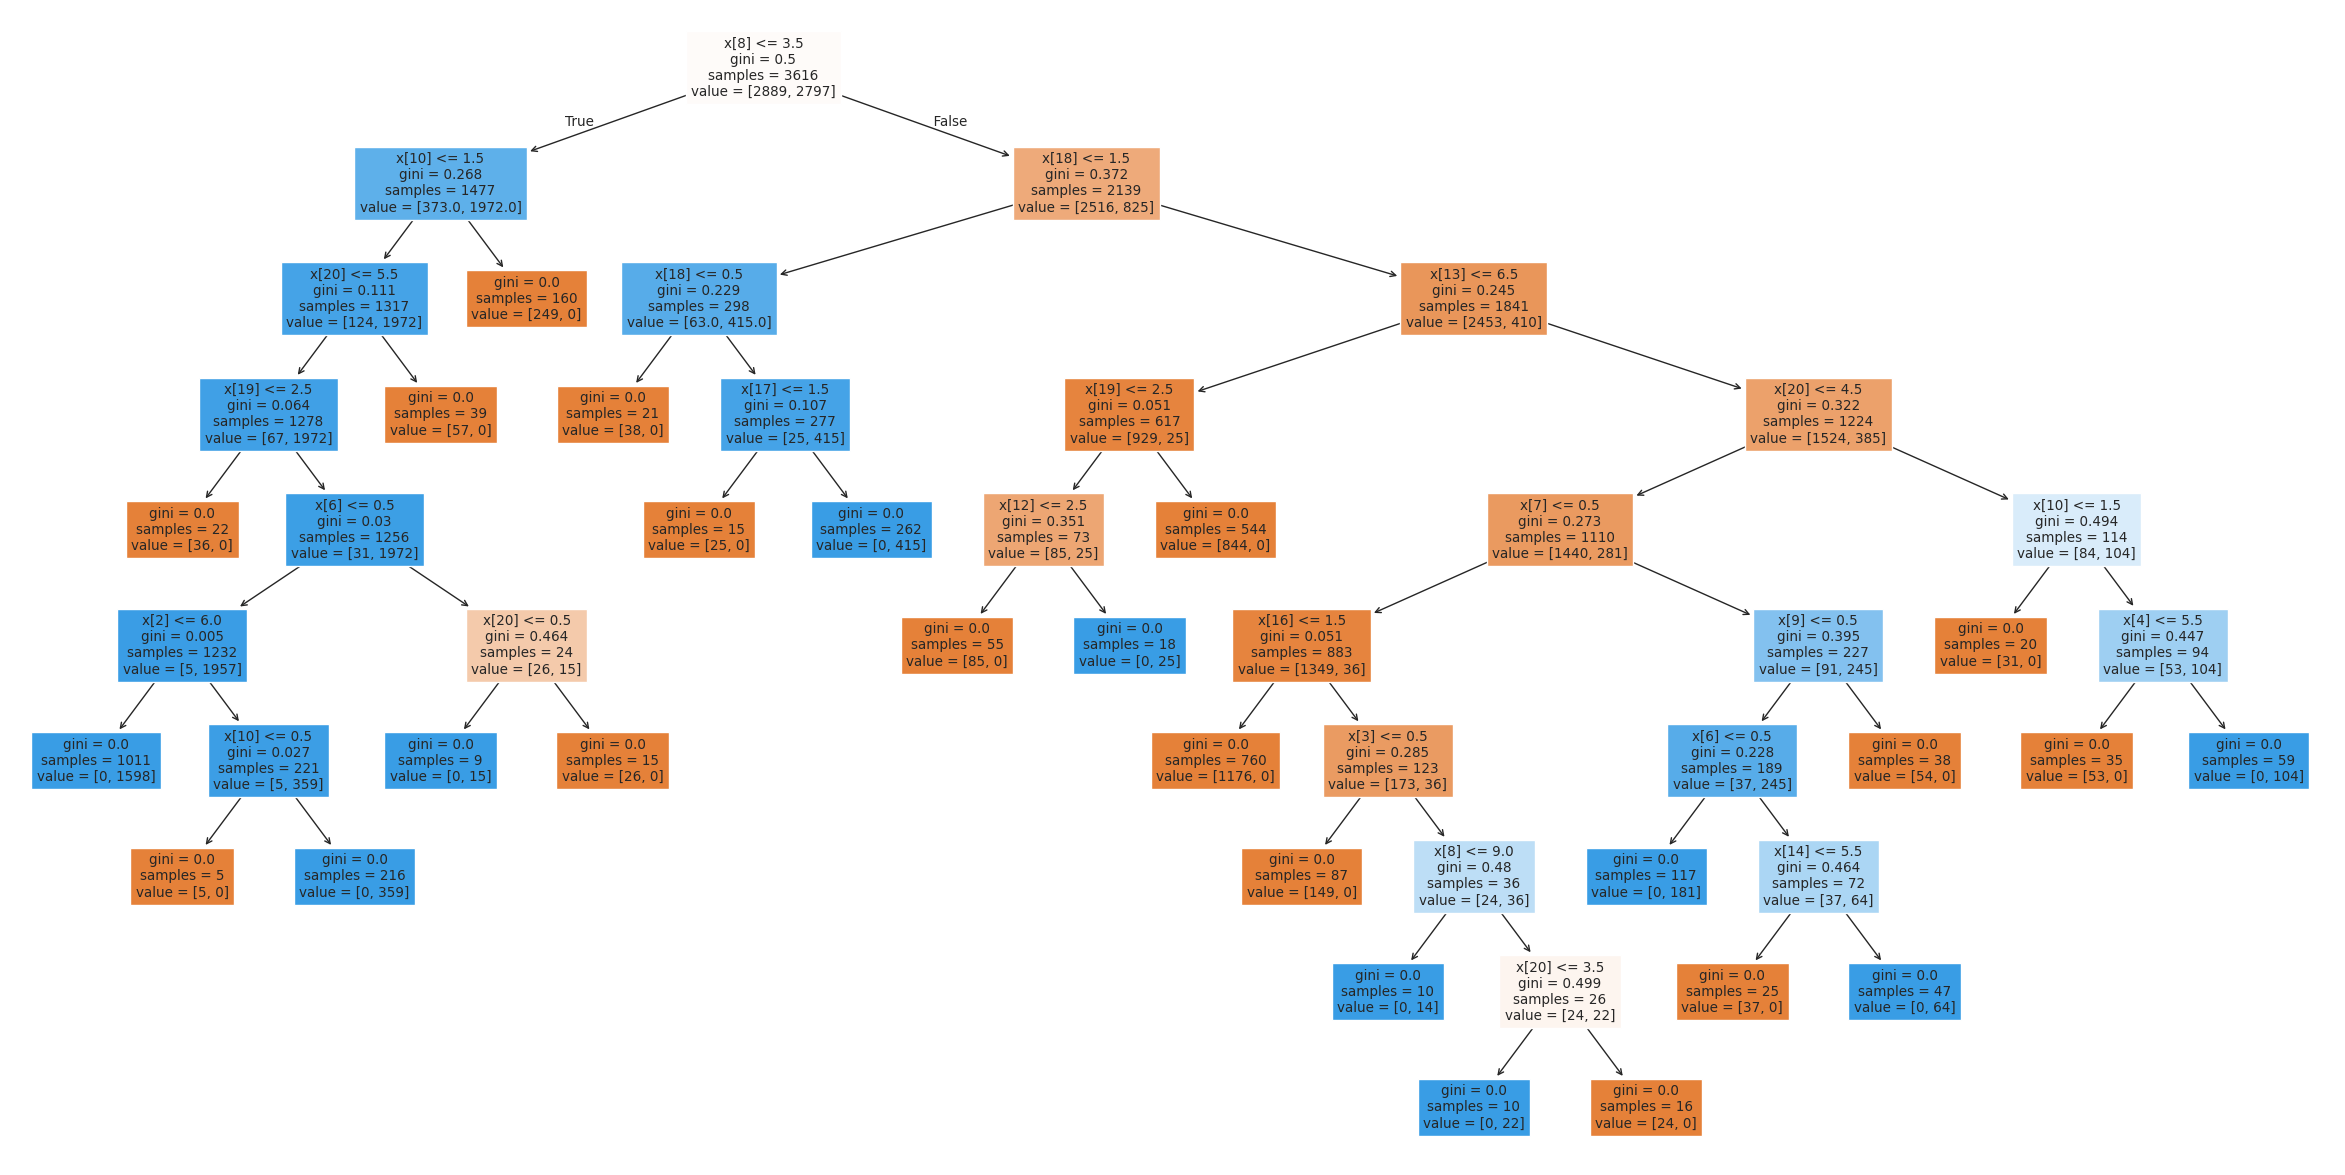

In [66]:
## plot one decision tree of the random forest
from sklearn import tree
plt.figure(figsize=(30,15))
tree.plot_tree(model.estimators_[0],filled=True)
plt.show()

In [67]:
confmat1 = confusion_matrix(y_predict, y_test)
confmat1

array([[1272,    0],
       [   0, 1166]])

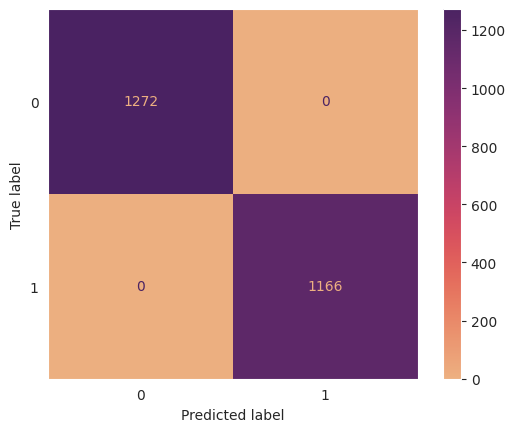

In [68]:
cm=metrics.ConfusionMatrixDisplay(confusion_matrix=metrics.confusion_matrix(y_predict,y_test,labels=model.classes_),
                              display_labels=model.classes_)
cm.plot(cmap="flare")

In [69]:
print('Accuracy: %.3f' % accuracy_score(y_predict, y_test)) # check accuracy

Accuracy: 1.000


In [70]:
y_test.value_counts() # number of records in each category

,count
class,
0,1272
1,1166


#Feature Engineering

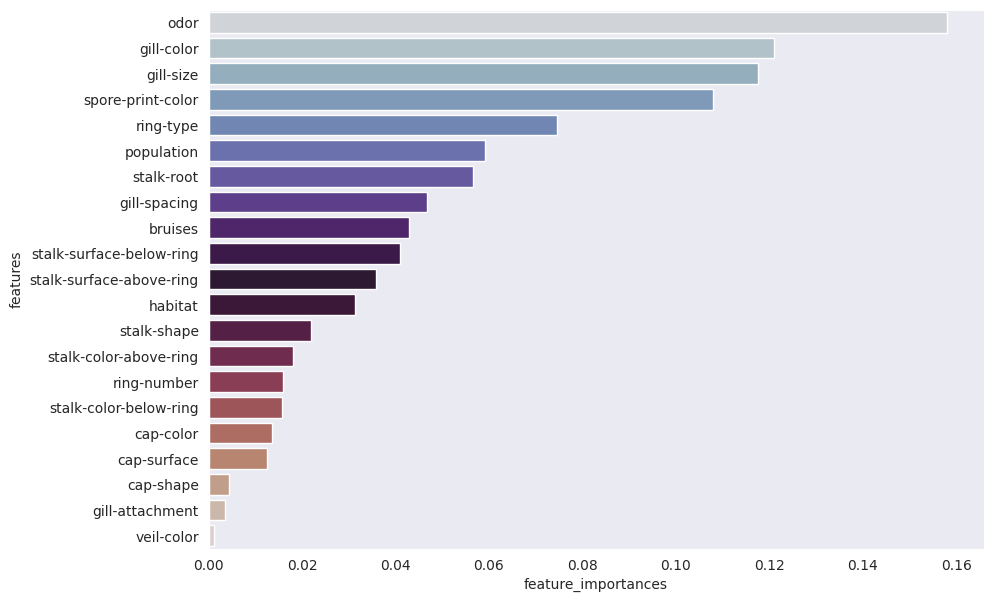

In [71]:
fi_df = pd.DataFrame({
    "feature_importances" : model.feature_importances_,
    "features" : x.columns
})

fi_df.sort_values(by="feature_importances", ascending=False, inplace=True)

plt.figure(figsize=(10,7))
sns.barplot(x="feature_importances", y="features", palette="twilight", data=fi_df)
plt.show()

In [72]:
accuracy_score(y_predict, y_test)

1.0